In [2]:
import pandas as pd
import matplotlib
import sqlite3

connection=sqlite3.connect('../data/checking-logs.sqlite')

In [3]:
df=pd.read_sql(sql='''WITH views AS (SELECT DATE(datetime) AS date, COUNT(*) as views FROM pageviews
               WHERE uid LIKE 'user%'
               GROUP BY date),
               
               commits AS (SELECT DATE(timestamp) AS date, COUNT(*) as commits
               FROM checker
               WHERE uid LIKE 'user%'
               GROUP BY date)
               
               SELECT views.date, views.views, commits.commits FROM views
               JOIN commits ON views.date = commits.date
               WHERE views.views > 0 AND commits.commits > 0;
               ''', con=connection)
df

,date,views,commits
0,2020-04-17,1,23
1,2020-04-18,23,69
2,2020-04-19,15,33
3,2020-04-21,3,25
4,2020-04-22,1,28
5,2020-04-23,5,43
6,2020-04-25,1,104
7,2020-04-26,8,261
8,2020-04-28,2,5
9,2020-04-29,4,17


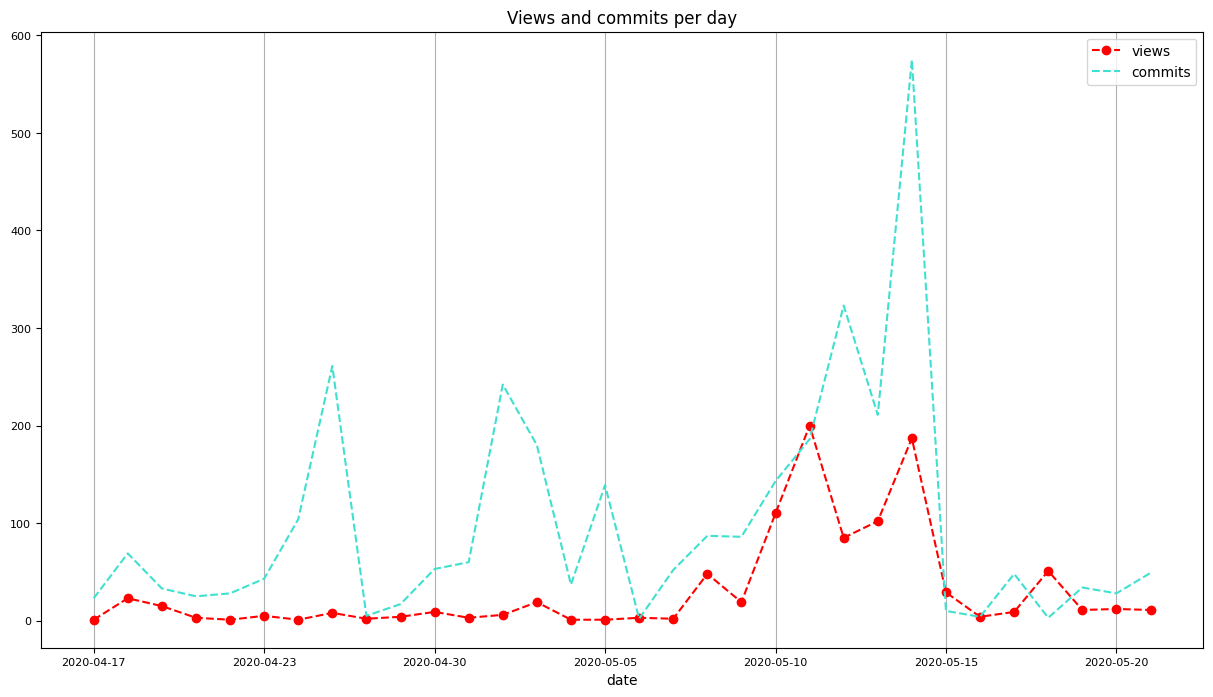

In [35]:
#import matplotlib.dates as mdates
axes=df.plot(x='date', y='views', color='red', figsize=(15,8), fontsize=8, style='o--')
df.plot(x='date', y='commits', color='turquoise', ax=axes, style='--')

axes.set_title('Views and commits per day')
axes.grid(axis='x')
#axes.xaxis.set_major_locator(mdates.DayLocator(interval=4))
#axes.set_facecolor('#E3E3E3')

In [25]:
df[df['views'] > 150]

,date,views,commits
21,2020-05-11,200,186
24,2020-05-14,187,575


How many times was the number of views larger than 150? 2

In [ ]:
connection.close()